In [21]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/ML-wakacyjne-wyzwanie-2026")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

Z wcześniejszej analizy (EDA) wiemy, że płeć i klasa biletu są kluczowe. Usunęliśmy za to kolumny typu Cabin (za dużo braków) czy unikalne numery biletów, bo to tylko stworzy niepotrzebny szum.

In [23]:
titanic_df = pd.read_csv(base_path / 'titanic_cleaned_data.csv', index_col='PassengerId')
display(titanic_df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,0,1,2,0
2,1,1,1,38.0,1,0,71.2833,1,0,0,2,0
3,1,3,1,26.0,0,0,7.9250,0,0,1,1,1
4,1,1,1,35.0,1,0,53.1000,0,0,1,2,0
5,0,3,0,35.0,0,0,8.0500,0,0,1,1,1


**Blokada wycieku danych:** Podział zbioru na część do nauki i część do testów przed jakimikolwiek przeróbkami. Zbiór testowy zostawiamy w spokoju aż do samego końca.

**Standaryzacja:** Wyrównanie szans cech

**Wybór metryk:** Głównym punktem odniesienia jest ogólna skuteczność (Accuracy). Jednak z racji tego, że na Titanicu zginęło znacznie więcej osób, niż przeżyło (zbiór jest niezbalansowany), również patrzę na F1-score dla klasy ocalałych. Zwykła skuteczność mogłaby dawać złudne poczucie dobrego modelu.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Wydzielenie cech i zmiennej doeclowej
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

# Podział na zbiory przed treningiem danych
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

**Model Bazowy (Baseline)**
Sprawdzamy, jak poradzi sobie model, który zawsze obstawia najczęstszy przypadek (brak przeżycia).

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Model Bazowy: Dummy Classifier")
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
y_pred = dummy_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Model Bazowy: Dummy Classifier
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

[[110   0]
 [ 69   0]]


**Pierwszy model**. Żeby nie nastąpiło przetrenowanie, szukamy dla niego optymalnej głębokości (max_depth) za pomocą GridSearchCV, który od razu stosuje bezpieczną kroswalidację.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

print("Model 1: Drzewo Decyzyjne")

tree_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree_model = DecisionTreeClassifier(random_state=42)
tree_grid_search = GridSearchCV(tree_model, tree_grid, cv=5, scoring='accuracy')

tree_grid_search.fit(X_train, y_train)
y_pred = tree_grid_search.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


print("Najlepsze ustawienia hiperparametrów:", tree_grid_search.best_params_)
print("Wynik na kroswalidacji:", round(tree_grid_search.best_score_, 3))
print("Ostateczny wynik na teście:", round(tree_grid_search.score(X_test, y_test), 3))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       110
           1       0.78      0.62      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179

[[98 12]
 [26 43]]
Najlepsze ustawienia hiperparametrów: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Wynik na kroswalidacji: 0.825
Ostateczny wynik na teście: 0.788


**Drugi model** to klasyczne szukanie podobieństw między pasażerami. Tutaj używamy przeskalowanych danych za pomocą Pipeline'a, aby zachować sens liczenia odległości. Sprawdzimy, ilu sąsiadów (n_neighbors) daje najlepszy wynik.

--- MODEL 2: KNN (K-najbliższych sąsiadów) ---
Najlepsze ustawienia: {'knn__metric': 'minkowski', 'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'uniform'}
Wynik na teście: 0.816


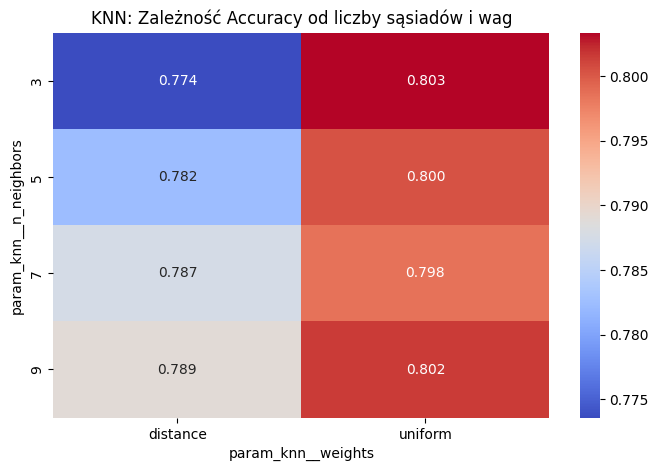

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- MODEL 2: KNN (K-najbliższych sąsiadów) ---")

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
    'knn__metric': ['euclidean', 'cosine', 'minkowski', 'manhattan']
}

knn_grid_search = GridSearchCV(knn_pipeline, knn_grid, cv=5, scoring='accuracy')

knn_grid_search.fit(X_train, y_train)

y_pred_knn = knn_grid_search.predict(X_test)

print("Najlepsze ustawienia:", knn_grid_search.best_params_)
print("Wynik na teście:", round(knn_grid_search.score(X_test, y_test), 3))

knn_table = pd.DataFrame(knn_grid_search.cv_results_)

pivot_table_knn = knn_table.pivot_table(
    index='param_knn__n_neighbors',
    columns='param_knn__weights',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table_knn, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("KNN: Zależność Accuracy od liczby sąsiadów i wag")
plt.show()

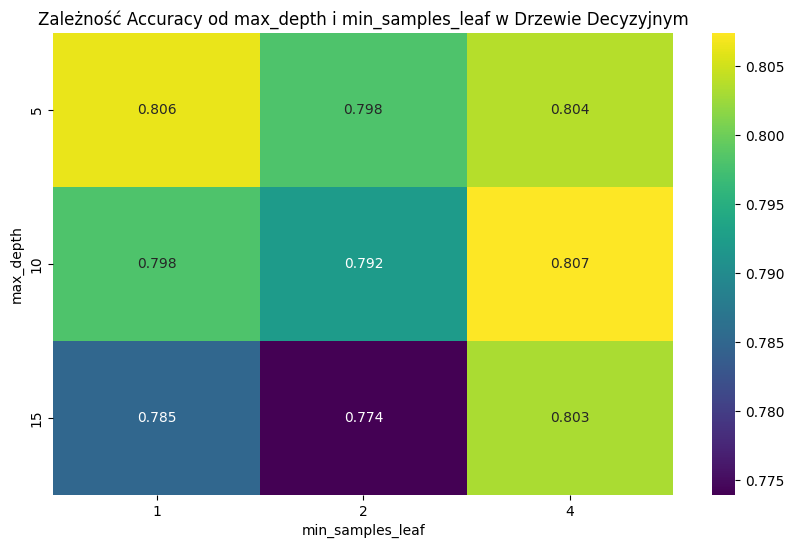

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


tree_table = pd.DataFrame(tree_grid_search.cv_results_)
pivot_table = tree_table.pivot_table(index='param_max_depth', columns='param_min_samples_leaf', values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".3f")
plt.title("Zależność Accuracy od max_depth i min_samples_leaf w Drzewie Decyzyjnym")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

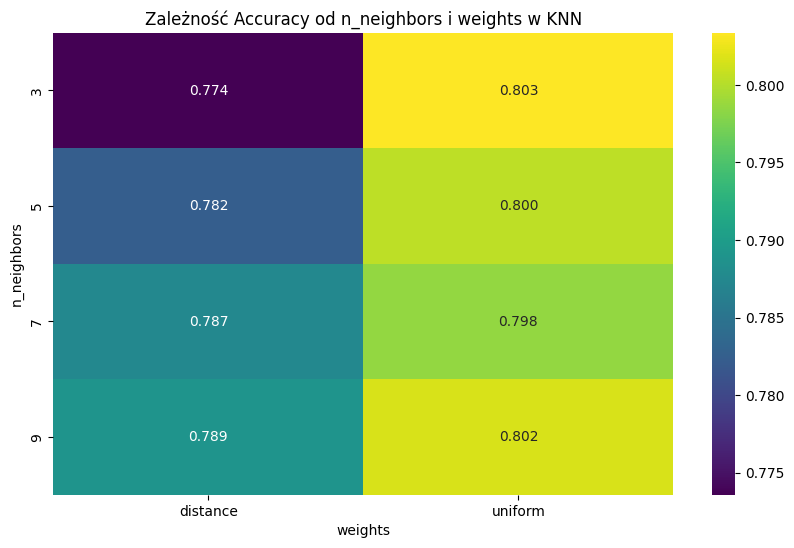

In [20]:
knn_table = pd.DataFrame(knn_grid_search.cv_results_)
pivot_table = knn_table.pivot_table(index='param_knn__n_neighbors', columns='param_knn__weights', values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".3f")
plt.title("Zależność Accuracy od n_neighbors i weights w KNN")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.show()

**Wnioski końcowe**

*   Ogólna skuteczność: Zwykły, naiwny DummyClassifier osiągnął dokładność rzędu 61%, bezlitośnie oblewając przewidywanie kto przeżyje (F1-score dla klasy ocalałych wynosił okrągłe 0). Natomiast zarówno Drzewo Decyzyjne, jak i KNN dobiły do okolic 79-82% na zbiorze testowym.
*   Co pokazały badania Drzewa? Z heatmapy widać, że brak limitu głębokości (max_depth = None) wcale nie zawsze jest super. Czasem model zbytnio zapamiętuje dane treningowe. Narzucenie mu max_depth = 10 okazało się strzałem w dziesiątkę.  
*   Co pokazały badania KNN? Na wykresie dla KNN wyraźnie widać, że dobór liczby sąsiadów (n_neighbors) to "być albo nie być" dla tego modelu. Mała liczba sąsiadów sprawia, że algorytm jest zbyt wrażliwy, a 9 sąsiadów uspokoiło jego predykcje dając najlepszy wynik. Oczywiście wszystko to zagrało tylko dlatego, że dane podane KNN-owi były uprzednio wystandaryzowane.  